In [1]:
# TECH CHALLENGE IA

In [2]:
## Introdução
# Neste desafio de análise de dados, será realizado um estudo com foco na classificação de informações por meio de um modelo de árvore de decisão, com o objetivo de auxiliar no diagnóstico de câncer a partir de um conjunto de dados disponibilizado pela biblioteca scikit-learn.

In [22]:
## Bibliotecas Python

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
from sklearn import preprocessing
from sklearn import model_selection
from sklearn.metrics import confusion_matrix, make_scorer, accuracy_score 
from sklearn.model_selection import learning_curve, StratifiedKFold, train_test_split
from sklearn.feature_selection import RFECV, SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
import graphviz 
from sklearn.datasets import load_breast_cancer
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Carrega base de dados de câncer de mama do sklearn
cancer = load_breast_cancer()

In [5]:
# concatenar arrays de dados e rótulos para criar um DataFrame
data = np.c_[cancer.data, cancer.target]


In [6]:
# criar lista de nomes de colunas para o DataFrame
columns = list(cancer.feature_names) + [np.str_("target")]

In [7]:
# Verificar se tem alguma coluna sem nome
print("Nomes das colunas: ", columns)

Nomes das colunas:  [np.str_('mean radius'), np.str_('mean texture'), np.str_('mean perimeter'), np.str_('mean area'), np.str_('mean smoothness'), np.str_('mean compactness'), np.str_('mean concavity'), np.str_('mean concave points'), np.str_('mean symmetry'), np.str_('mean fractal dimension'), np.str_('radius error'), np.str_('texture error'), np.str_('perimeter error'), np.str_('area error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('concavity error'), np.str_('concave points error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst compactness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry'), np.str_('worst fractal dimension'), np.str_('target')]


In [8]:
# criar DataFrame usando os dados e os nomes das colunas
df = pd.DataFrame(data, columns=columns)

In [56]:
# verificar tamanho do daaframe
df.shape

(569, 31)

In [ ]:
#Quantidade de colunas não exige uso de PCA

In [9]:
# printar as primeiras linhas do DataFrame para verificar os dados
print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [ ]:
# Antes de qualquer coisa precisamos validar os dados, e verificar se não há nenhum valor que precisa de normalização ou correção.

In [10]:
# verificar se há valores ausentes no DataFrame
print(df.isna().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [11]:
# verificar se há valores nulos no DataFrame
print(df.isnull().sum())


mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [41]:
# verificar se há valores duplicados no DataFrame
print(df.duplicated().sum())

0


In [ ]:
#Não existe valores nulos, em branco ou duplicados no dataset

In [17]:
#Separando dados em 80% train e 20% test
y = df.target
X = df[df.columns[:-1]]
X_train, X_test, Y_train, Y_test = train_test_split(X, y, test_size=0.20)

In [43]:
# Analise Exploratória

#Quais variaveis mais defininem entre benigno ou maligno?
#Qual a dispersão das variaveis?

In [44]:
#Usar o camando describe para visualizar o desvio padrão, médias, mínimos e máximos
X.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [46]:
# Variáveis com escalas muito diferentes precisam ser padronizadas.
# Padronização das variáveis (StandardScaler).
# para evitar que features de maior magnitude dominem o modelo.

scaler = preprocessing.StandardScaler()

# Aplica o StandardScaler em todas as features de X
X_scaled = pd.DataFrame(
        scaler.fit_transform(X),
        columns=X.columns
)

# Aplica também nos conjuntos de treino e teste
X_train_scaled = pd.DataFrame(
        scaler.fit_transform(X_train),
        columns=X_train.columns
)


#usando transform garante que o modelo de teste seja avaliado com a mesma escala do treino, evitando vazamento de dados (data leakage).
X_test_scaled = pd.DataFrame(
        scaler.transform(X_test),
        columns=X_test.columns
)

print("\nEstatísticas após padronização (X_scaled):")
print(X_scaled.describe().loc[['mean', 'std']].round(4))

Padronização concluída!

Estatísticas após padronização (X_scaled):
      mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
mean      -0.0000       -0.0000         -0.0000    -0.0000           0.0000   
std        1.0009        1.0009          1.0009     1.0009           1.0009   

      mean compactness  mean concavity  mean concave points  mean symmetry  \
mean           -0.0000         -0.0000               0.0000        -0.0000   
std             1.0009          1.0009               1.0009         1.0009   

      mean fractal dimension  ...  worst radius  worst texture  \
mean                 -0.0000  ...       -0.0000         0.0000   
std                   1.0009  ...        1.0009         1.0009   

      worst perimeter  worst area  worst smoothness  worst compactness  \
mean          -0.0000      0.0000           -0.0000            -0.0000   
std            1.0009      1.0009            1.0009             1.0009   

      worst concavity  worst concave 

Número de Benignos:  269
Número of Malignos :  157


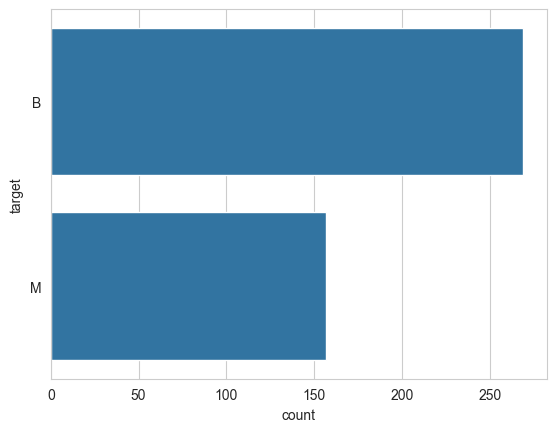

In [50]:
# visualização da distribuição dos rótulos de classe
y = Y_train.replace(0,'M').replace(1,'B') #Converte 0 e 1 para M e B para criar gráfico

# cria gráfico
ax = sns.countplot(y,label="Count")

# printar quantidade
B, M = y.value_counts()
print('Número de Benignos: ',B)
print('Número of Malignos : ',M)

In [ ]:
# Features como 'worst area' (std ≈ 569) e 'mean area' (std ≈ 351) apresentam grande dispersão, o que indica que podem ter alto poder discriminativo entre tumores malignos e benignos

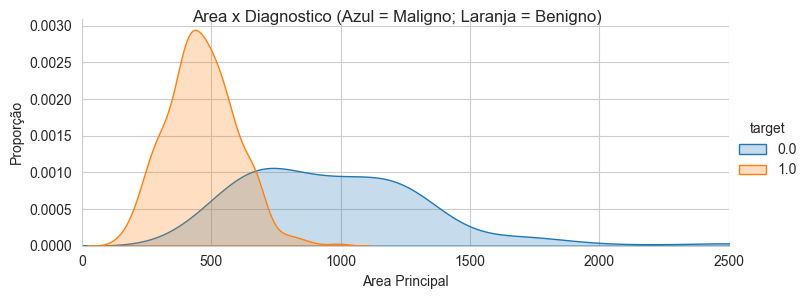

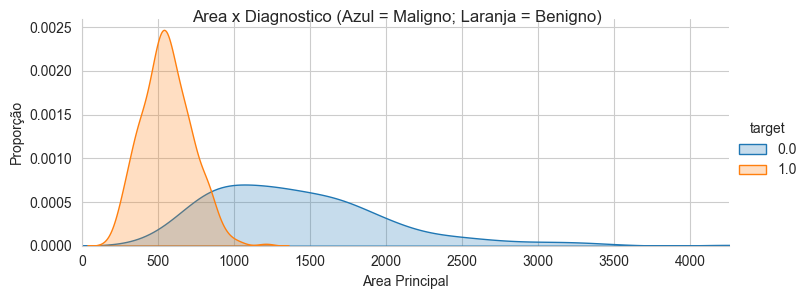

In [57]:
#Gráficos para analisar separadamente as Features com grande dispersão
# mean area
sns.set_style("whitegrid")
plotOne = sns.FacetGrid(df, hue="target",aspect=2.5)
plotOne.map(sns.kdeplot,'mean area',shade=True)
plotOne.set(xlim=(0, df['mean area'].max()))
plotOne.add_legend()
plotOne.set_axis_labels('Area Principal', 'Proporção')
plotOne.fig.suptitle('Area x Diagnostico (Azul = Maligno; Laranja = Benigno)')
plt.show()

#worst area
sns.set_style("whitegrid")
plotOne = sns.FacetGrid(df, hue="target",aspect=2.5)
plotOne.map(sns.kdeplot,'worst area',shade=True)
plotOne.set(xlim=(0, df['worst area'].max()))
plotOne.add_legend()
plotOne.set_axis_labels('Area Principal', 'Proporção')
plotOne.fig.suptitle('Area x Diagnostico (Azul = Maligno; Laranja = Benigno)')
plt.show()



### Mean Area (Área Média)
  - - As duas distribuições apresentam **sobreposição parcial** na faixa de 500–1000, o que indica que a feature possui poder discriminativo, mas não é suficiente isoladamente para separar as classes com precisão.
   
    

### Worst Area (Pior Área — valor máximo registrado)
- - A separação entre as classes é **mais nítida** do que na `mean area`, com menor sobreposição, o que indica que **`worst area` possui maior poder discriminativo** para o modelo.
       
### Conclusão Geral
Ambas as features confirmam a tendência observada na célula 44: **tumores malignos tendem a ter áreas maiores e mais dispersas**, enquanto tumores benignos apresentam áreas menores e mais concentradas. A feature `worst area` demonstra ser especialmente relevante para a classificação, pois a separação entre as classes é mais clara — o que justifica sua alta importância no modelo de Decision Tree treinado na célula 47.

        RESULTADOS - Decision Tree
Acurácia: 95.80%

Relatório de Classificação:
              precision    recall  f1-score   support

     Maligno       0.96      0.93      0.94        55
     Benigno       0.96      0.98      0.97        88

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.96       143
weighted avg       0.96      0.96      0.96       143



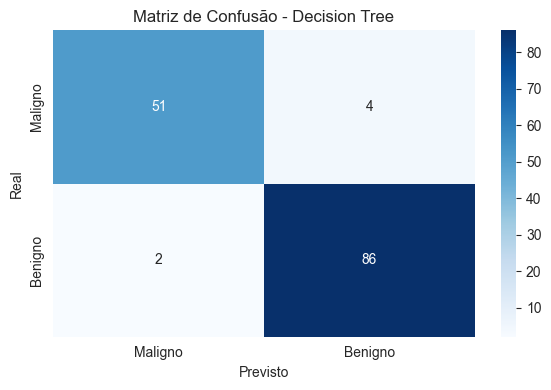

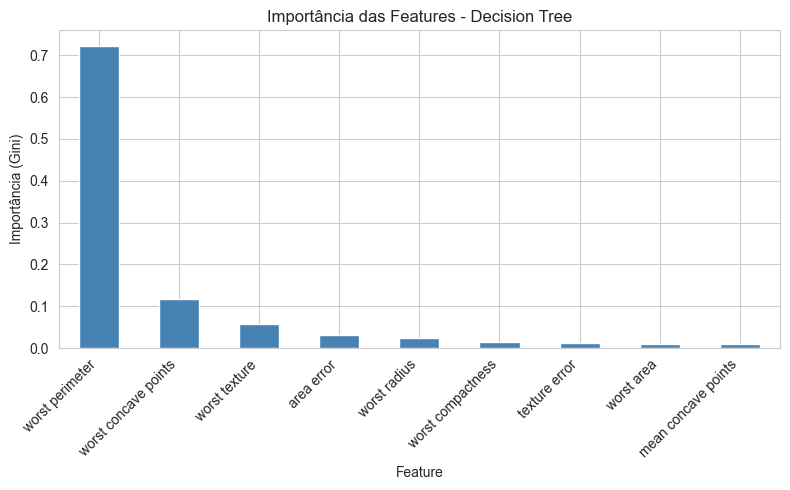

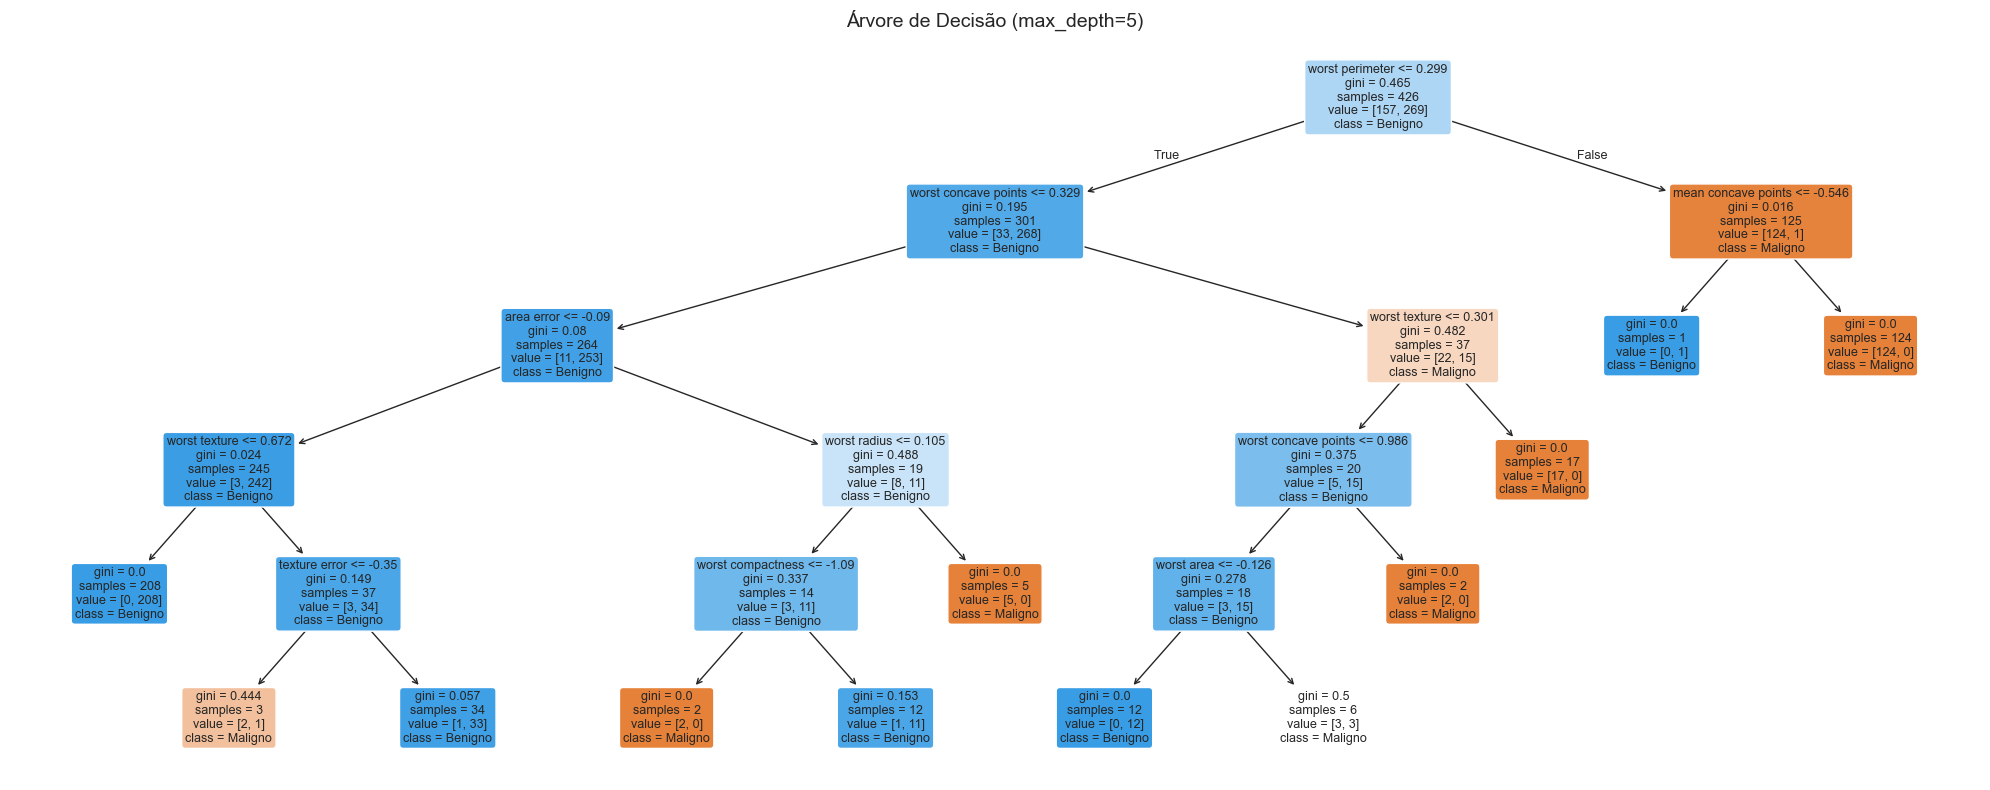

In [47]:
# ============================================================
# TREINAMENTO - Decision Tree Classifier
# ============================================================

# --- 1. Treinamento do modelo ---
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
dt_model.fit(X_train_scaled, Y_train)

# --- 2. Predição ---
Y_pred = dt_model.predict(X_test_scaled)

# --- 3. Métricas de avaliação ---
acc = accuracy_score(Y_test, Y_pred)
print("=" * 50)
print("        RESULTADOS - Decision Tree")
print("=" * 50)
print(f"Acurácia: {acc * 100:.2f}%")
print()
print("Relatório de Classificação:")
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred, target_names=["Maligno", "Benigno"]))

# --- 4. Matriz de Confusão ---
cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                        xticklabels=["Maligno", "Benigno"],
                        yticklabels=["Maligno", "Benigno"])
plt.title("Matriz de Confusão - Decision Tree")
plt.ylabel("Real")
plt.xlabel("Previsto")
plt.tight_layout()
plt.show()

# --- 5. Importância das features ---
feat_importance = pd.Series(dt_model.feature_importances_, index=X_train.columns)
feat_importance = feat_importance[feat_importance > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
feat_importance.plot(kind='bar', color='steelblue')
plt.title("Importância das Features - Decision Tree")
plt.ylabel("Importância (Gini)")
plt.xlabel("Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- 6. Visualização da Árvore de Decisão ---
plt.figure(figsize=(20, 8))
tree.plot_tree(dt_model,
                              feature_names=list(X_train.columns),
                              class_names=["Maligno", "Benigno"],
                              filled=True,
                              rounded=True,
                              fontsize=9)
plt.title("Árvore de Decisão (max_depth=5)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
## Métricas de desempenho:

#Acurácia: 95.80% — excelente resultado para o conjunto de teste
#Precision/Recall/F1 para Maligno: 0.96 / 0.93 / 0.94
#Precision/Recall/F1 para Benigno: 0.96 / 0.98 / 0.97

In [11]:

### Por que Acurácia?
#A acurácia mede a proporção de predições corretas sobre o total. Ela foi usada como métrica primária porque o dataset do Breast Cancer Wisconsin apresenta um desbalanceamento moderado e aceitável: 357 benignos contra 212 malignos (distribuição ~63%/37%). Quando as classes não são extremamente desiguais, a acurácia ainda é uma métrica informativa e fácil de interpretar. O resultado de 95.80% diz, de forma direta, que o modelo acertou 137 dos 143 casos no conjunto de teste.



## Por que F1-score?
# O F1-score é a média harmônica entre Precision e Recall, e foi incluído por uma razão crítica: o contexto médico exige cautela com os dois tipos de erro possíveis.
# No diagnóstico de câncer, os erros não têm o mesmo peso:
#• Um Falso Negativo (dizer que é benigno quando é maligno) pode fazer o paciente não receber tratamento e é potencialmente fatal.
#• Um Falso Positivo (dizer que é maligno quando é benigno) causa ansiedade e exames desnecessários, mas é menos grave.
# O F1-score captura esse equilíbrio. Olhando os resultados da célula 47, percebe-se que a classe Maligno obteve F1 = 0.94, com Recall = 0.93 — ou seja, o modelo identificou corretamente 51 dos 55 casos malignos no teste (deixou escapar apenas 4 como falsos negativos, visíveis na Matriz de Confusão). Isso é um resultado relevante em termos clínicos.

#---

#Por que as duas juntas?
#A acurácia sozinha pode mascarar problemas. Imagine um modelo que sempre prevê "benigno": em um dataset 63/37, ele teria ~63% de acurácia, mas F1 de 0 para a classe Maligno — ou seja, seria completamente inútil clinicamente. Usar as duas métricas em conjunto garante uma visão mais completa e honesta do desempenho real do modelo para ambas as classes.
